# Comprehensive Statistical Analysis of Synthetic End-to-End Results

This notebook demonstrates a comprehensive statistical evaluation of **5 methods x 6 variants x 5 folds** from a balance-guided oblique decision tree experiment.

**Eight analyses are performed:**
- **(A)** Friedman + Nemenyi method ranking
- **(B)** XOR significance testing (paired t-tests, Cohen's d)
- **(C)** Module-accuracy Spearman correlation
- **(D)** Pareto frontier (accuracy vs interpretability)
- **(E)** No-structure control analysis
- **(F)** High-dimensional failure diagnosis
- **(G)** Signed vs unsigned spectral effect size (Hedges' g)
- **(H)** Success criteria assessment

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# scikit-posthocs — NOT on Colab, always install
_pip('scikit-posthocs==0.11.0')

# Core packages (pre-installed on Colab, install locally to match Colab env)
# Colab versions: numpy==2.0.2, scipy==1.16.3, matplotlib==3.10.0
# For Python <3.11, scipy>=1.16 is unavailable; use latest compatible
if 'google.colab' not in sys.modules:
    if sys.version_info >= (3, 11):
        _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')
    else:
        _pip('numpy==2.0.2', 'scipy==1.15.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import sys
from itertools import combinations

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/evaluation_iter4_comprehensive_s/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with keys: {list(data.keys())}")
print(f"Number of dataset variants: {len(data['datasets'])}")
print(f"Metrics: {list(data['metrics_agg'].keys())}")

Loaded data with keys: ['metrics_agg', 'method_ranking', 'xor_analysis', 'pareto_analysis', 'signed_vs_unsigned', 'no_structure_analysis', 'highdim_diagnosis', 'success_criteria', 'datasets']
Number of dataset variants: 6
Metrics: ['pooled_friedman_p', 'grand_mean_bacc_axis_aligned', 'grand_mean_bacc_random_oblique', 'grand_mean_bacc_signed_spectral', 'grand_mean_bacc_unsigned_spectral', 'grand_mean_bacc_hard_threshold', 'module_acc_spearman_rho', 'module_acc_spearman_p', 'signed_vs_unsigned_hedges_g', 'xor_unsigned_vs_axis_cohens_d', 'success_criteria_confirmed', 'success_criteria_disconfirmed', 'total_runtime_s']


In [5]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
# Number of bootstrap resamples
N_BOOTSTRAP = 10000  # full original value
RNG = np.random.default_rng(42)

METHODS = [
    "axis_aligned", "random_oblique", "signed_spectral",
    "unsigned_spectral", "hard_threshold",
]
VARIANTS = [
    "easy_2mod_xor", "medium_4mod_mixed", "overlapping_modules",
    "no_structure_control", "hard_4mod_unequal", "highdim_8mod",
]

## Statistical Helper Functions

Core functions from the evaluation script for computing effect sizes, bootstrap confidence intervals, and non-parametric tests.

In [6]:
def cohens_d(x: np.ndarray, y: np.ndarray) -> float:
    """Paired Cohen's d (mean diff / pooled SD)."""
    diff = x - y
    sd = np.std(diff, ddof=1)
    if sd == 0:
        return 0.0
    return float(np.mean(diff) / sd)


def hedges_g(x: np.ndarray, y: np.ndarray) -> float:
    """Hedges' g: bias-corrected Cohen's d for small samples."""
    n = len(x)
    d = cohens_d(x, y)
    j = 1 - 3 / (4 * (2 * n - 2) - 1)
    return float(d * j)


def interpret_effect(g: float) -> str:
    """Interpret Hedges' g / Cohen's d magnitude."""
    ag = abs(g)
    if ag < 0.2:
        return "negligible"
    elif ag < 0.5:
        return "small"
    elif ag < 0.8:
        return "medium"
    else:
        return "large"


def bootstrap_mean_diff(x: np.ndarray, y: np.ndarray, n_boot: int = N_BOOTSTRAP) -> tuple:
    """Bootstrap 95% CI for mean(x - y)."""
    diff = x - y
    n = len(diff)
    boot_means = np.array([
        np.mean(RNG.choice(diff, size=n, replace=True)) for _ in range(n_boot)
    ])
    return float(np.percentile(boot_means, 2.5)), float(np.percentile(boot_means, 97.5))


def safe_wilcoxon(x: np.ndarray, y: np.ndarray) -> dict:
    """Wilcoxon signed-rank test, handling ties and zero diffs."""
    diff = x - y
    nonzero = diff[diff != 0]
    if len(nonzero) < 2:
        return {"stat": None, "p_value": None, "note": "insufficient non-zero differences"}
    try:
        stat, p = stats.wilcoxon(x, y, method='exact')
        return {"stat": float(stat), "p_value": float(p)}
    except ValueError:
        try:
            stat, p = stats.wilcoxon(x, y, method='approx')
            return {"stat": float(stat), "p_value": float(p)}
        except Exception:
            return {"stat": None, "p_value": None, "note": "wilcoxon failed"}


def safe_ttest_rel(x: np.ndarray, y: np.ndarray) -> dict:
    """Paired t-test with CI for mean difference."""
    n = len(x)
    diff = x - y
    mean_diff = float(np.mean(diff))
    try:
        t_stat, p_value = stats.ttest_rel(x, y)
        se = float(np.std(diff, ddof=1) / np.sqrt(n))
        t_crit = stats.t.ppf(0.975, df=n - 1)
        ci_lower = mean_diff - t_crit * se
        ci_upper = mean_diff + t_crit * se
        return {
            "t_stat": float(t_stat), "p_value": float(p_value),
            "mean_diff": mean_diff, "ci_lower": float(ci_lower),
            "ci_upper": float(ci_upper),
        }
    except Exception:
        return {"t_stat": None, "p_value": None, "mean_diff": mean_diff,
                "ci_lower": None, "ci_upper": None}


print("Helper functions defined.")

Helper functions defined.


## Analysis A: Method Ranking (Friedman + Nemenyi)

Friedman test across all 30 blocks (6 variants x 5 folds) determines whether methods differ significantly in rank. Nemenyi post-hoc identifies which pairs differ.

In [7]:
# Extract method ranking results
ranking = data['method_ranking']
pooled = ranking['pooled']

print("=== Pooled Friedman Test (all 30 blocks) ===")
print(f"  Chi2 = {pooled['friedman_chi2']:.3f}")
print(f"  p-value = {pooled['friedman_p']:.4f}")
print(f"  N blocks = {pooled['n_blocks']}")
print()

print("=== Average Ranks (lower = better) ===")
for method, rank in sorted(pooled['avg_ranks'].items(), key=lambda x: x[1]):
    print(f"  {method:25s}: {rank:.3f}")

print()
cd = ranking['critical_difference']
print(f"Critical Difference (CD) = {cd['cd_value']:.4f} at alpha=0.05")
print(f"  Methods within CD of each other are NOT significantly different.")

print()
print("=== Per-Variant Friedman p-values ===")
for var, vr in ranking['per_variant'].items():
    sig = "*" if vr['friedman_p'] is not None and vr['friedman_p'] < 0.05 else " "
    p_str = f"{vr['friedman_p']:.4f}" if vr['friedman_p'] is not None else "N/A"
    print(f"  {sig} {var:25s}: p={p_str}")

=== Pooled Friedman Test (all 30 blocks) ===
  Chi2 = 11.296
  p-value = 0.0234
  N blocks = 30

=== Average Ranks (lower = better) ===
  hard_threshold           : 2.333
  unsigned_spectral        : 2.667
  axis_aligned             : 3.300
  signed_spectral          : 3.333
  random_oblique           : 3.367

Critical Difference (CD) = 1.1137 at alpha=0.05
  Methods within CD of each other are NOT significantly different.

=== Per-Variant Friedman p-values ===
  * easy_2mod_xor            : p=0.0033
    medium_4mod_mixed        : p=0.1338
  * overlapping_modules      : p=0.0333
  * no_structure_control     : p=0.0058
    hard_4mod_unequal        : p=0.0976
    highdim_8mod             : p=0.1525


## Analysis B: XOR Significance Testing

Paired significance tests on the `easy_2mod_xor` variant, where oblique methods are expected to shine due to the XOR structure requiring multi-feature splits.

In [8]:
# Extract XOR analysis results
xor = data['xor_analysis']

print("=== XOR Paired t-tests (easy_2mod_xor variant) ===")
for pair, result in xor['paired_tests'].items():
    sig = "*" if result['p_value'] is not None and result['p_value'] < 0.05 else " "
    print(f"  {sig} {pair}:")
    print(f"      t={result['t_stat']:.3f}, p={result['p_value']:.4f}, "
          f"mean_diff={result['mean_diff']:.4f}")
    print(f"      95% CI: [{result['ci_lower']:.4f}, {result['ci_upper']:.4f}]")

print()
print("=== Effect Sizes (Cohen's d) ===")
for pair, es in xor['effect_sizes'].items():
    print(f"  {pair}: d={es['cohens_d']:.3f} ({es['interpretation']})")

print()
bs = xor['bootstrap_ci']
print(f"=== Bootstrap CI ({bs['comparison']}) ===")
print(f"  95% CI: [{bs['lower']:.4f}, {bs['upper']:.4f}] (n_resamples={bs['n_resamples']})")

=== XOR Paired t-tests (easy_2mod_xor variant) ===
  * unsigned_spectral_vs_axis_aligned:
      t=3.355, p=0.0284, mean_diff=0.1236
      95% CI: [0.0213, 0.2260]
    unsigned_spectral_vs_random_oblique:
      t=-0.407, p=0.7046, mean_diff=-0.0079
      95% CI: [-0.0619, 0.0461]
    signed_spectral_vs_axis_aligned:
      t=-0.673, p=0.5376, mean_diff=-0.0437
      95% CI: [-0.2237, 0.1364]
  * hard_threshold_vs_axis_aligned:
      t=3.338, p=0.0289, mean_diff=0.1244
      95% CI: [0.0209, 0.2279]

=== Effect Sizes (Cohen's d) ===
  unsigned_spectral_vs_axis_aligned: d=1.500 (large)
  unsigned_spectral_vs_random_oblique: d=-0.182 (negligible)
  signed_spectral_vs_axis_aligned: d=-0.301 (small)
  hard_threshold_vs_axis_aligned: d=1.493 (large)

=== Bootstrap CI (unsigned_spectral_vs_axis_aligned) ===
  95% CI: [0.0608, 0.1865] (n_resamples=10000)


## Analysis D: Pareto Frontier (Accuracy vs Interpretability)

Pareto analysis shows the trade-off between accuracy and split arity (interpretability). Lower arity = more interpretable. Points on the Pareto frontier are not dominated by any other method.

In [9]:
# Extract Pareto analysis results
pareto = data['pareto_analysis']

print("=== Efficiency Ratio (accuracy / arity) ===")
for method, ratio in sorted(pareto['efficiency_ratio'].items(), key=lambda x: -x[1]):
    print(f"  {method:25s}: {ratio:.4f}")

print()
print("=== Pareto-Optimal Methods per Variant ===")
for var, info in pareto['per_variant'].items():
    print(f"  {var:25s}: {', '.join(info['pareto_optimal'])}")

# Re-derive Pareto frontier from scatter data
scatter = pareto['scatter_data']
print(f"\nScatter data: {len(scatter)} points (method x variant)")
for pt in scatter[:5]:
    print(f"  {pt['method']:20s} | {pt['variant']:25s} | acc={pt['accuracy']:.4f} | arity={pt['arity']:.2f}")

=== Efficiency Ratio (accuracy / arity) ===
  axis_aligned             : 0.6979
  hard_threshold           : 0.2988
  signed_spectral          : 0.2922
  unsigned_spectral        : 0.2471
  random_oblique           : 0.2383

=== Pareto-Optimal Methods per Variant ===
  easy_2mod_xor            : axis_aligned, random_oblique, hard_threshold
  medium_4mod_mixed        : axis_aligned
  overlapping_modules      : axis_aligned
  no_structure_control     : axis_aligned, unsigned_spectral, hard_threshold
  hard_4mod_unequal        : axis_aligned, unsigned_spectral
  highdim_8mod             : axis_aligned, signed_spectral, hard_threshold

Scatter data: 30 points (method x variant)
  axis_aligned         | easy_2mod_xor             | acc=0.6047 | arity=1.00
  random_oblique       | easy_2mod_xor             | acc=0.7362 | arity=1.96
  signed_spectral      | easy_2mod_xor             | acc=0.5610 | arity=1.68
  unsigned_spectral    | easy_2mod_xor             | acc=0.7283 | arity=1.98
  hard_th

## Analysis E & F: No-Structure Control and High-Dimensional Diagnosis

Analysis E examines the no-structure control (no planted modules) to check if spectral methods find genuine structure. Analysis F diagnoses why signed spectral collapses on high-dimensional data.

In [10]:
# Analysis E: No-structure control
no_struct = data['no_structure_analysis']
print("=== No-Structure Control: Method Accuracies ===")
for m, acc in sorted(no_struct['method_accuracies'].items(),
                     key=lambda x: -x[1]['mean']):
    print(f"  {m:25s}: mean={acc['mean']:.4f}, std={acc['std']:.4f}")

print()
print("=== No-Structure: Arity Comparison ===")
for m, arity in no_struct['arity_comparison'].items():
    print(f"  {m:25s}: {arity:.2f}")

# Analysis F: High-dimensional diagnosis
print()
highdim = data['highdim_diagnosis']
print("=== Highdim (200 features, 8 modules): Method Comparison ===")
for m, info in highdim['method_comparison'].items():
    print(f"  {m:25s}: acc={info['accuracy']:.4f}, arity={info['arity']:.2f}, "
          f"path_len={info['path_length']:.3f}")

print()
print("=== Selected k values (spectral clustering) ===")
for m, ks in highdim['selected_k'].items():
    print(f"  {m:25s}: {ks}")

=== No-Structure Control: Method Accuracies ===
  unsigned_spectral        : mean=0.9062, std=0.0087
  random_oblique           : mean=0.8947, std=0.0097
  hard_threshold           : mean=0.8940, std=0.0116
  signed_spectral          : mean=0.8718, std=0.0356
  axis_aligned             : mean=0.8157, std=0.0047

=== No-Structure: Arity Comparison ===
  axis_aligned             : 1.00
  random_oblique           : 5.85
  signed_spectral          : 3.45
  unsigned_spectral        : 5.50
  hard_threshold           : 3.00

=== Highdim (200 features, 8 modules): Method Comparison ===
  axis_aligned             : acc=0.6851, arity=1.00, path_len=4.667
  random_oblique           : acc=0.6744, arity=1.77, path_len=4.705
  signed_spectral          : acc=0.6851, arity=1.00, path_len=4.667
  unsigned_spectral        : acc=0.6755, arity=1.70, path_len=4.619
  hard_threshold           : acc=0.6851, arity=1.00, path_len=4.667

=== Selected k values (spectral clustering) ===
  signed_spectral         

## Analysis G: Signed vs Unsigned Spectral (Hedges' g)

Compares signed (SPONGE) vs unsigned spectral clustering across all variants using Hedges' g effect size. Negative g means unsigned wins.

In [11]:
# Extract signed vs unsigned results
svu = data['signed_vs_unsigned']

print("=== Per-Variant Hedges' g (signed - unsigned) ===")
for var, info in svu['per_variant'].items():
    arrow = "<" if info['diff'] < 0 else ">"
    print(f"  {var:25s}: g={info['hedges_g']:+.3f} ({info['interpretation']}), "
          f"signed={info['signed_mean']:.4f} {arrow} unsigned={info['unsigned_mean']:.4f}")

print()
print(f"=== Pooled Hedges' g: {svu['pooled']['pooled_g']:.4f} ({svu['pooled']['interpretation']})")
print(f"  Bootstrap 95% CI: [{svu['pooled']['bootstrap_ci_lower']:.4f}, "
      f"{svu['pooled']['bootstrap_ci_upper']:.4f}]")

print()
wlt = svu['win_loss_tie']
print(f"=== Win/Loss/Tie: signed_wins={wlt['signed_wins']}, "
      f"unsigned_wins={wlt['unsigned_wins']}, ties={wlt['ties']}") 

# Re-derive effect size demonstration using helper functions
signed_means = np.array([v['signed_mean'] for v in svu['per_variant'].values()])
unsigned_means = np.array([v['unsigned_mean'] for v in svu['per_variant'].values()])
demo_g = hedges_g(signed_means, unsigned_means)
print(f"\nDemo: re-computed Hedges' g from variant means = {demo_g:.4f} ({interpret_effect(demo_g)})")
ci = bootstrap_mean_diff(signed_means, unsigned_means, n_boot=N_BOOTSTRAP)
print(f"  Bootstrap CI for mean diff: [{ci[0]:.4f}, {ci[1]:.4f}]")

=== Per-Variant Hedges' g (signed - unsigned) ===
  easy_2mod_xor            : g=-1.893 (large), signed=0.5610 < unsigned=0.7283
  medium_4mod_mixed        : g=-0.182 (negligible), signed=0.7560 < unsigned=0.7576
  overlapping_modules      : g=+0.583 (medium), signed=0.7574 > unsigned=0.7516
  no_structure_control     : g=-0.972 (large), signed=0.8718 < unsigned=0.9062
  hard_4mod_unequal        : g=-0.624 (medium), signed=0.6115 < unsigned=0.6703
  highdim_8mod             : g=+0.638 (medium), signed=0.6851 > unsigned=0.6755

=== Pooled Hedges' g: -0.5260 (medium)
  Bootstrap 95% CI: [-0.7823, -0.2887]

=== Win/Loss/Tie: signed_wins=2, unsigned_wins=4, ties=0

Demo: re-computed Hedges' g from variant means = -0.5648 (medium)
  Bootstrap CI for mean diff: [-0.0942, -0.0009]


## Analysis H: Success Criteria Assessment

Evaluates 4 confirmation and 3 disconfirmation criteria to determine whether the signed spectral (SPONGE) hypothesis holds.

In [12]:
# Extract success criteria results
sc = data['success_criteria']

print("=== Success Criteria ===")
for key in ['criterion_1', 'criterion_2', 'criterion_3', 'criterion_4']:
    c = sc[key]
    print(f"  {key}: {c['verdict']}")

print()
print("=== Disconfirmation Criteria ===")
for key in ['disconfirmation_1', 'disconfirmation_2', 'disconfirmation_3']:
    d = sc[key]
    print(f"  {key}: {d['verdict']}")

print()
print("=== Overall Verdict ===")
print(sc['overall_verdict'])

=== Success Criteria ===
  criterion_1: DISCONFIRMED
  criterion_2: INCONCLUSIVE
  criterion_3: CONFIRMED
  criterion_4: CONFIRMED

=== Disconfirmation Criteria ===
  disconfirmation_1: TRIGGERED
  disconfirmation_2: NOT_TRIGGERED
  disconfirmation_3: NOT_TRIGGERED

=== Overall Verdict ===
Of 4 success criteria: 2 CONFIRMED, 1 DISCONFIRMED, 1 INCONCLUSIVE. Of 3 disconfirmation criteria: 1 TRIGGERED. The signed spectral (SPONGE) approach fails its primary module recovery criterion. Unsigned spectral shows promise but does not validate the signed information hypothesis. The pipeline meets runtime constraints. Frustration-benefit correlation is inconclusive with only 6 data points.


## Visualization

Four-panel summary: (1) method ranking, (2) Pareto frontier, (3) signed vs unsigned effect sizes, (4) grand mean accuracies.

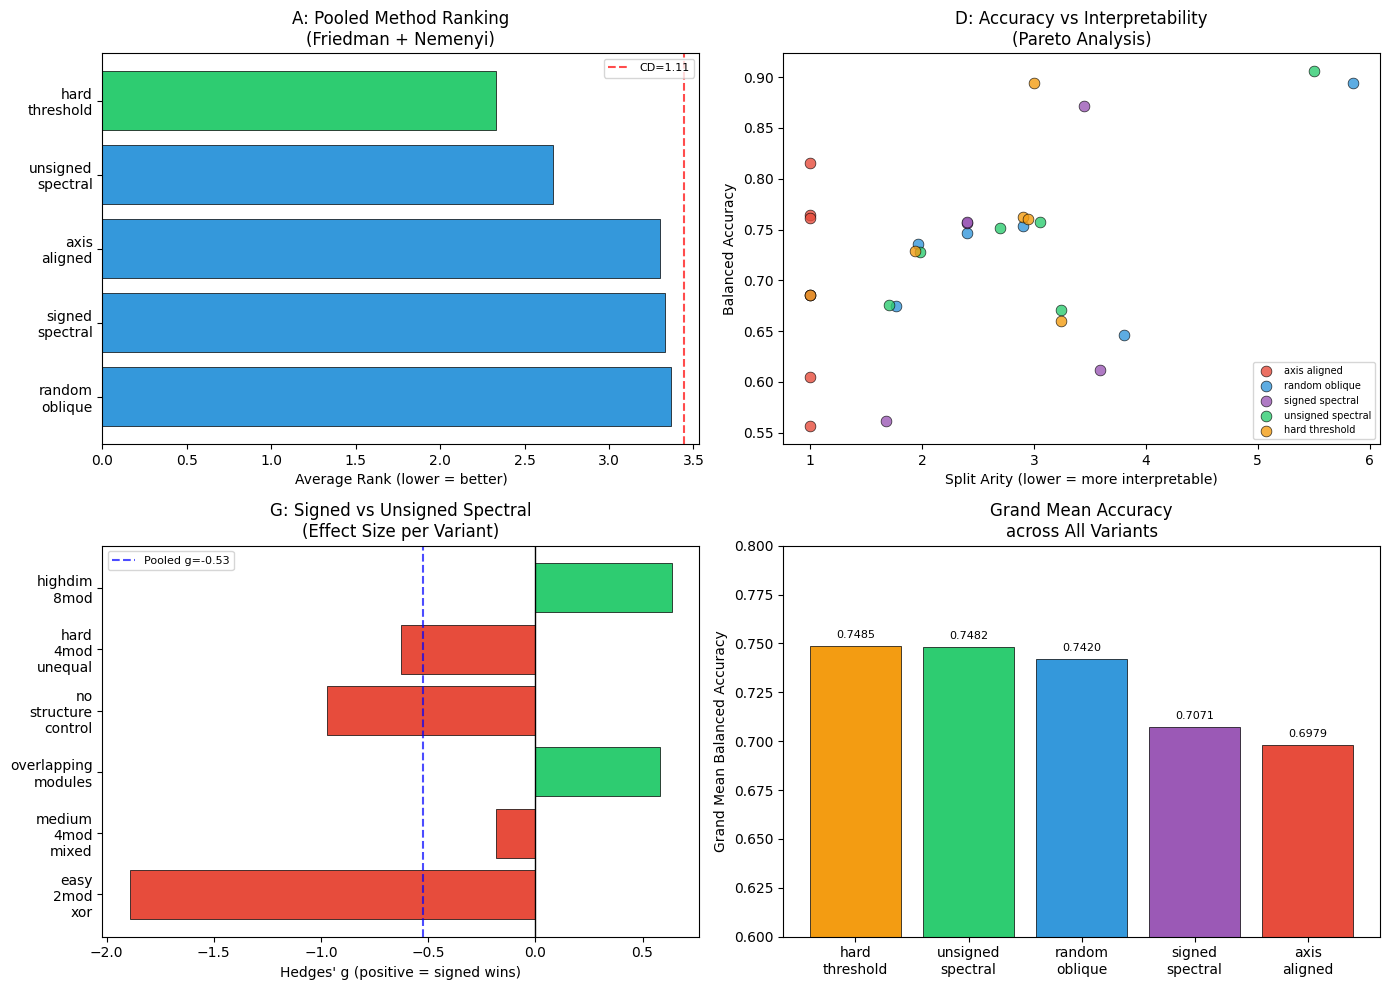

Saved eval_summary.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Method Ranking (average ranks, lower = better) ---
ax = axes[0, 0]
ranks = data['method_ranking']['pooled']['avg_ranks']
methods_sorted = sorted(ranks.keys(), key=lambda m: ranks[m])
rank_vals = [ranks[m] for m in methods_sorted]
short_names = [m.replace('_', '\n') for m in methods_sorted]
colors = ['#2ecc71' if ranks[m] == min(rank_vals) else '#3498db' for m in methods_sorted]
bars = ax.barh(short_names, rank_vals, color=colors, edgecolor='black', linewidth=0.5)
cd_val = data['method_ranking']['critical_difference']['cd_value']
ax.axvline(x=min(rank_vals) + cd_val, color='red', linestyle='--', alpha=0.7, label=f'CD={cd_val:.2f}')
ax.set_xlabel('Average Rank (lower = better)')
ax.set_title('A: Pooled Method Ranking\n(Friedman + Nemenyi)')
ax.legend(fontsize=8)
ax.invert_yaxis()

# --- Panel 2: Pareto Frontier (Accuracy vs Arity) ---
ax = axes[0, 1]
scatter = data['pareto_analysis']['scatter_data']
method_colors = {
    'axis_aligned': '#e74c3c', 'random_oblique': '#3498db',
    'signed_spectral': '#9b59b6', 'unsigned_spectral': '#2ecc71',
    'hard_threshold': '#f39c12'
}
for m in METHODS:
    pts = [p for p in scatter if p['method'] == m]
    if pts:
        ax.scatter([p['arity'] for p in pts], [p['accuracy'] for p in pts],
                   c=method_colors.get(m, 'gray'), label=m.replace('_', ' '),
                   s=60, alpha=0.8, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Split Arity (lower = more interpretable)')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('D: Accuracy vs Interpretability\n(Pareto Analysis)')
ax.legend(fontsize=7, loc='lower right')

# --- Panel 3: Signed vs Unsigned Effect Size ---
ax = axes[1, 0]
svu = data['signed_vs_unsigned']['per_variant']
variants_short = [v.replace('_', '\n') for v in VARIANTS]
g_vals = [svu[v]['hedges_g'] for v in VARIANTS]
bar_colors = ['#2ecc71' if g > 0 else '#e74c3c' for g in g_vals]
ax.barh(variants_short, g_vals, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=data['signed_vs_unsigned']['pooled']['pooled_g'],
           color='blue', linestyle='--', alpha=0.7,
           label=f"Pooled g={data['signed_vs_unsigned']['pooled']['pooled_g']:.2f}")
ax.set_xlabel("Hedges' g (positive = signed wins)")
ax.set_title('G: Signed vs Unsigned Spectral\n(Effect Size per Variant)')
ax.legend(fontsize=8)

# --- Panel 4: Grand Mean Balanced Accuracy ---
ax = axes[1, 1]
metrics = data['metrics_agg']
method_accs = {m: metrics[f'grand_mean_bacc_{m}'] for m in METHODS}
methods_sorted_acc = sorted(method_accs.keys(), key=lambda m: -method_accs[m])
acc_vals = [method_accs[m] for m in methods_sorted_acc]
short_names_acc = [m.replace('_', '\n') for m in methods_sorted_acc]
colors_acc = [method_colors.get(m, 'gray') for m in methods_sorted_acc]
ax.bar(short_names_acc, acc_vals, color=colors_acc, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Grand Mean Balanced Accuracy')
ax.set_title('Grand Mean Accuracy\nacross All Variants')
ax.set_ylim(0.6, 0.8)
for i, v in enumerate(acc_vals):
    ax.text(i, v + 0.003, f'{v:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('eval_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved eval_summary.png")